In [2]:
import matplotlib
import cv2 as cv
import scipy.signal as signal
from scipy.signal import butter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import scipy.fft as fft
from PIL import Image, ImageSequence

(Text(0.5, 1.0, 'Downscaled'), [], [])

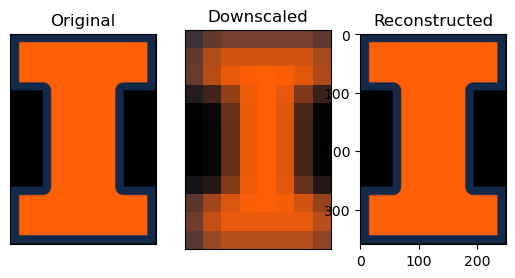

In [2]:

# Returns a "levels"-deep Laplacian pyramid of the given frame
def pyramidDownSample(frame, levels=5):
    G = frame.astype(np.float32)
    samples = [G]

    for i in range(levels):
        G = cv.pyrDown(G)
        samples.append(G)
    laplacianBase = samples[levels]
    laplacians = []
    for i in range(levels,0,-1):
        upsampled = cv.pyrUp(samples[i])
        upsampled = cv.resize(upsampled, (samples[i-1].shape[1], samples[i-1].shape[0]))
        L = cv.subtract(samples[i-1].astype(np.float32), upsampled.astype(np.float32))
        laplacians.append(L)
    
    return laplacianBase, laplacians

# Reconstructs the original image
def pyramidReconstruct(base, laplacians):
    G = base.astype(np.float32)
    for L in laplacians:
        G = cv.pyrUp(G)
        G = cv.resize(G, (L.shape[1], L.shape[0]))
        G = cv.add(G, L.astype(np.float32))
    return G

image = cv.imread("illinois.png")
lB, lS = pyramidDownSample(image)
reconstructed = pyramidReconstruct(lB, lS)
reconstructed = np.clip(reconstructed, 0, 255,).astype(np.uint8)
fig, axes = plt.subplots(1, 3)
axes[0].imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
axes[0].set_title('Original'), axes[0].set_xticks([]), axes[0].set_yticks([])
axes[2].imshow(cv.cvtColor(reconstructed, cv.COLOR_BGR2RGB))
axes[2].set_title('Reconstructed'), axes[1].set_xticks([]), axes[1].set_yticks([])
lB = np.clip(lB, 0, 255).astype(np.uint8)
axes[1].imshow(cv.cvtColor(lB, cv.COLOR_BGR2RGB))
axes[1].set_title('Downscaled'), axes[1].set_xticks([]), axes[1].set_yticks([])




In [35]:
video = cv.VideoCapture("guitar-strumming.gif")
fps = video.get(cv.CAP_PROP_FPS)
print(fps)

10.0


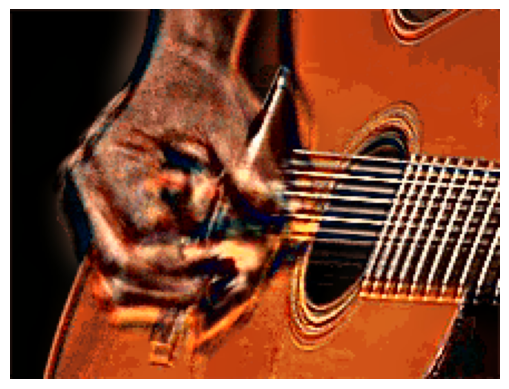

In [34]:
# Ideal Temporal Filter

levels = 3
alpha = 10
laplacian_stack = [[] for _ in range(levels)]
base_stack = []

while(True):
    ret, levelFrame = video.read()
    if not ret:
        break
    baseFrame, laplacians = pyramidDownSample(cv.cvtColor(levelFrame, cv.COLOR_BGR2YUV), levels)
    base_stack.append(baseFrame)
    for i in range(levels):
        laplacian_stack[i].append(laplacians[i])

video.release()
cv.destroyAllWindows()

for i in range(levels):
    laplacian_stack[i] = np.array(laplacian_stack[i])
base_stack = np.array(base_stack)

N = len(base_stack)
freqs = np.fft.fftfreq(N, d=(1.0/fps))
mask = (np.abs(freqs) >= 0.83) & (np.abs(freqs) <= 1.0)

amplified_ls = []

for stack in laplacian_stack:
    decomp = np.fft.fft(stack, axis=0)
    decomp[~mask] = 0
    filtered = np.fft.ifft(decomp, axis=0).real
    amplified_stack = stack + (alpha * filtered)
    amplified_ls.append(amplified_stack)

final_frames = []
for e in range(len(base_stack)):
    currlap = [amplified_ls[i][e] for i in range(levels)]
    reconstructed = pyramidReconstruct(base_stack[e], currlap)
    final_rgb = cv.cvtColor(np.clip(reconstructed, 0, 255).astype(np.uint8), cv.COLOR_YUV2RGB)
    final_frames.append(final_rgb)

fig, ax = plt.subplots()
ax.axis('off')
im = ax.imshow(final_frames[0])
def update(frame):
    im.set_data(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=final_frames, interval=50, blit=True)
ani.save("temporaloutput.mp4")


In [106]:
video = cv.VideoCapture("guitar-strumming.gif")
fps = video.get(cv.CAP_PROP_FPS)
print(fps)

10.0


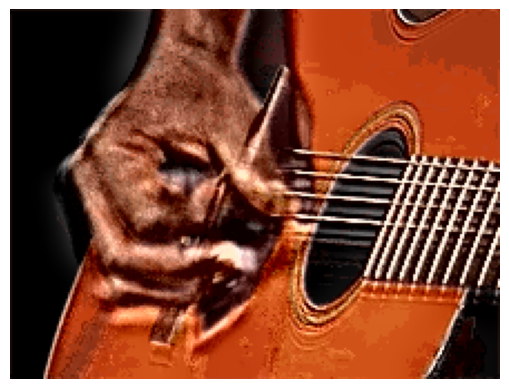

In [107]:
# Butterworth Filter
final_frames = []
levels = 3
alpha = 10
laplacian_stack = [[] for _ in range(levels)]
base_stack = []
b, a = butter(N=1, Wn=[0.83, 1.0], btype='bandpass', fs=fps)

ret, first_frame = video.read()
if ret:
    y_init, _, _ = cv.split(cv.cvtColor(first_frame, cv.COLOR_BGR2YUV))
    _, lap_init = pyramidDownSample(y_init, levels)
    prev_x = [[np.zeros_like(l, dtype=np.float32), np.zeros_like(l, dtype=np.float32)] for l in lap_init]
    prev_y = [[np.zeros_like(l, dtype=np.float32), np.zeros_like(l, dtype=np.float32)] for l in lap_init]
    video.set(cv.CAP_PROP_POS_FRAMES, 0)

while(True):
    ret, frame = video.read()
    if not ret: break

    yuv_frame = cv.cvtColor(frame, cv.COLOR_BGR2YUV)
    y, u, v = cv.split(yuv_frame)
    y_float = y.astype(np.float32) 
    base_img, laplacians = pyramidDownSample(y_float, levels)
    
    current_frame_laplacians = []
    
    for i in range(levels):
        x_curr = laplacians[i]
        
        y_curr = (b[0]*x_curr + b[1]*prev_x[i][0] + b[2]*prev_x[i][1] 
                  - a[1]*prev_y[i][0] - a[2]*prev_y[i][1]) / a[0]
        
        prev_x[i][1] = prev_x[i][0]
        prev_x[i][0] = x_curr
        prev_y[i][1] = prev_y[i][0]
        prev_y[i][0] = y_curr
        
        amplified_l = x_curr + (alpha * y_curr)
        current_frame_laplacians.append(amplified_l)

    reconstructed = pyramidReconstruct(base_img.astype(np.float32), current_frame_laplacians)
    recon_y = np.clip(reconstructed, 0, 255).astype(np.uint8)
    final_yuv = cv.merge([recon_y, u, v])
    final_bgr = cv.cvtColor(final_yuv, cv.COLOR_YUV2BGR)
    final_rgb = cv.cvtColor(final_bgr, cv.COLOR_BGR2RGB)
    final_frames.append(final_rgb)

video.release()
cv.destroyAllWindows()



fig, ax = plt.subplots()
ax.axis('off')
im = ax.imshow(final_frames[0])
def update(frame):
    im.set_data(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=final_frames, interval=50, blit=True)
ani.save("butterworthoutput.mp4")


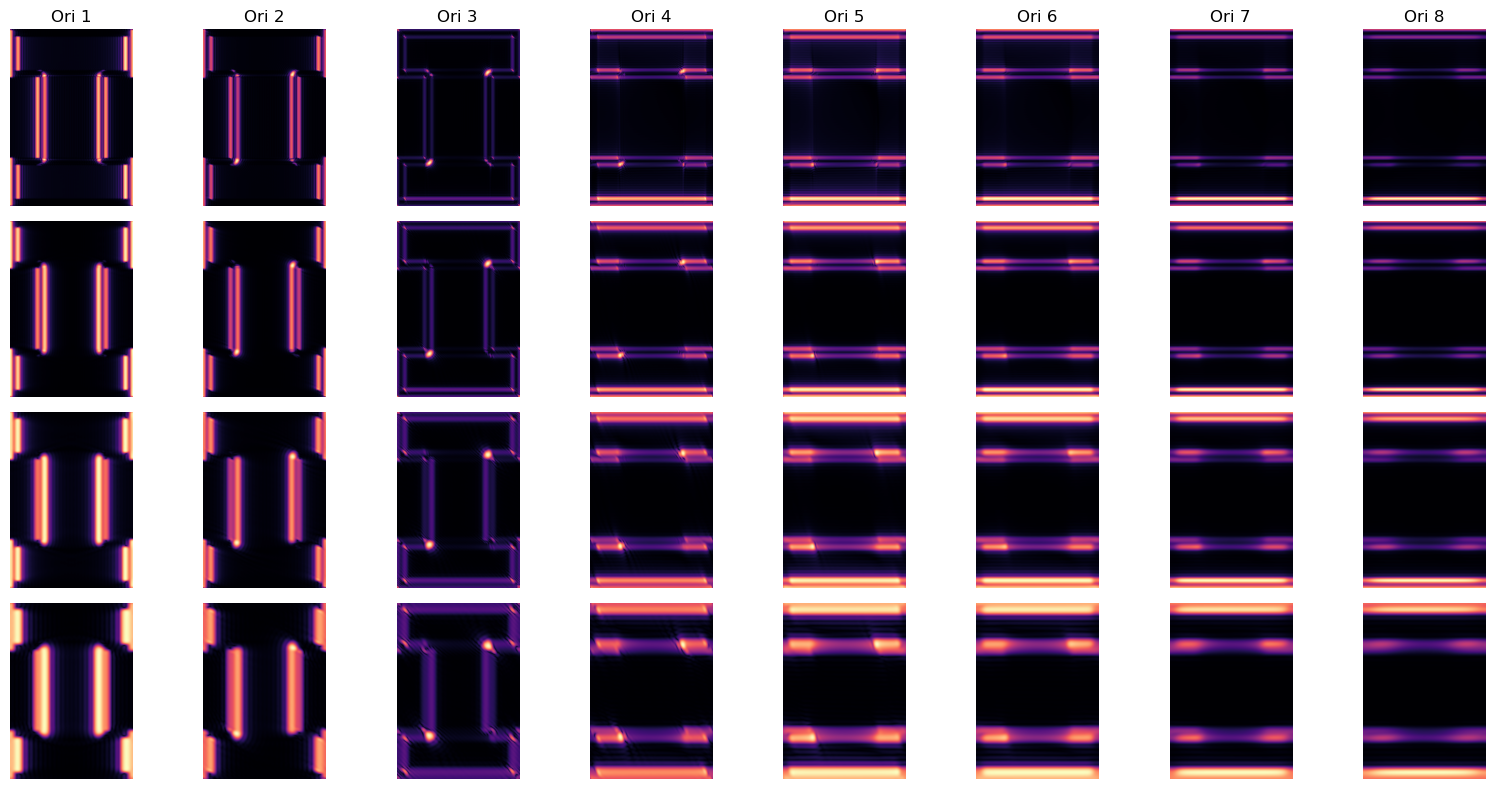

In [3]:
# Complex steerable pyramid decomposition (Wadhwa et al., 2013)

from math import factorial


def _wrap_to_pi(theta):
    return (theta + np.pi) % (2 * np.pi) - np.pi


def _frequency_grid(h, w):
    fy = np.fft.fftfreq(h)
    fx = np.fft.fftfreq(w)
    wx, wy = np.meshgrid(fx, fy)
    wx = np.fft.fftshift(wx)
    wy = np.fft.fftshift(wy)

    radius = np.sqrt(wx ** 2 + wy ** 2)
    radius[radius == 0] = np.finfo(np.float32).eps
    angle = np.arctan2(wy, wx)
    return radius, angle, wx, wy


def _analytic_half_plane_mask(wx, wy):
    """
    One-sided frequency mask for complex steerable filters.
    Implements the paper's positive-frequency-only oriented bands.
    """
    mask = np.zeros_like(wx, dtype=np.float32)
    pos = (wx > 0) | ((wx == 0) & (wy > 0))
    boundary = (wx == 0) & (wy == 0)
    mask[pos] = 2.0
    mask[boundary] = 1.0
    return mask


def _raised_cosine_log_radial(radius, center_log2, filters_per_octave):
    """
    Radial window in log-frequency domain.
    filters_per_octave = 1 -> octave; 2 -> half-octave; 4 -> quarter-octave.
    """
    t = filters_per_octave * (np.log2(radius) - center_log2)
    mask = np.zeros_like(radius, dtype=np.float32)
    support = np.abs(t) <= 1.0
    mask[support] = np.cos((np.pi / 2.0) * t[support])
    return mask


def _angular_mask(angle, k, orientations):
    """Steerable angular window (Portilla/Simoncelli form used by Wadhwa et al.)."""
    order = orientations - 1
    theta_k = (np.pi * k) / orientations
    delta = _wrap_to_pi(angle - theta_k)

    mask = np.zeros_like(angle, dtype=np.float32)
    support = np.abs(delta) <= (np.pi / 2.0)
    mask[support] = np.cos(delta[support]) ** order

    norm = (2 ** order) * factorial(order) / np.sqrt(orientations * factorial(2 * order))
    return norm * mask


def complex_steerable_pyramid_decompose(frame, num_scales=3, orientations=8, filters_per_octave=2):
    """
    Decompose image into a complex steerable pyramid.

    This follows Wadhwa et al. (2013):
    - frequency-domain filtering,
    - complex oriented bands from positive frequencies only,
    - configurable octave/sub-octave radial tiling.

    Returns:
      {
        "highpass": real high-frequency residual,
        "bands": list[num_radial_bands] of list[orientations] complex bands,
        "lowpass": real low-frequency residual,
        "meta": {...}
      }
    """
    if frame.ndim == 3:
        gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    else:
        gray = frame
    gray = gray.astype(np.float32)

    h, w = gray.shape
    F = np.fft.fftshift(np.fft.fft2(gray))
    radius, angle, wx, wy = _frequency_grid(h, w)
    analytic_mask = _analytic_half_plane_mask(wx, wy)

    n_bands = num_scales * filters_per_octave

    nyquist_log2 = np.log2(0.5)
    centers = [nyquist_log2 - (i + 0.5) / filters_per_octave for i in range(n_bands)]

    radial_masks = [_raised_cosine_log_radial(radius, c, filters_per_octave) for c in centers]

    highpass_mask = 1.0 - np.clip(np.sum(radial_masks[:filters_per_octave], axis=0), 0.0, 1.0)
    lowpass_mask = (radius <= (2 ** (centers[-1] - 0.5 / filters_per_octave))).astype(np.float32)

    highpass = np.fft.ifft2(np.fft.ifftshift(F * highpass_mask)).real
    lowpass = np.fft.ifft2(np.fft.ifftshift(F * lowpass_mask)).real

    bands = []
    for radial in radial_masks:
        per_orientation = []
        for k in range(orientations):
            ang = _angular_mask(angle, k, orientations)
            band_fft = F * radial * ang * analytic_mask
            per_orientation.append(np.fft.ifft2(np.fft.ifftshift(band_fft)))
        bands.append(per_orientation)

    return {
        "highpass": highpass,
        "bands": bands,
        "lowpass": lowpass,
        "meta": {
            "num_scales": num_scales,
            "orientations": orientations,
            "filters_per_octave": filters_per_octave,
            "num_radial_bands": n_bands,
        },
    }

def complex_steerable_pyramid_reconstruct(pyr): # generated this
    """
    Reconstructs the image from the complex steerable pyramid.
    """
    reconstructed = pyr["lowpass"].astype(np.float32) + pyr["highpass"].astype(np.float32)
    for scale_bands in pyr["bands"]:
        for band in scale_bands:
            reconstructed += band.real  # imaginary part cancels by conjugate symmetry
    return np.clip(reconstructed, 0, 255).astype(np.uint8)

# Sanity-check visualization (paper default is often 8 orientations, half-octave)
img = cv.imread("illinois.png")
pyr = complex_steerable_pyramid_decompose(img, num_scales=2, orientations=8, filters_per_octave=2)

rows = pyr["meta"]["num_radial_bands"]
cols = pyr["meta"]["orientations"]
fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
if rows == 1:
    axes = np.expand_dims(axes, axis=0)

for s in range(rows):
    for k in range(cols):
        coeff = pyr["bands"][s][k]
        axes[s, k].imshow(np.log1p(np.abs(coeff)), cmap="magma")
        axes[s, k].axis("off")
        if s == 0:
            axes[s, k].set_title(f"Ori {k + 1}")

plt.tight_layout()

In [3]:
video = cv.VideoCapture("guitar6.mp4")
fps = video.get(cv.CAP_PROP_FPS)
print(fps)

30.0


In [5]:
def get_phasesamps(pyr):
    phases = []
    amplitudes = []
    for s in range(len(pyr["bands"])):
        scale_phases = []
        scale_amplitudes = []
        for o in range(len(pyr["bands"][s])):
            scale_phases.append(np.angle(pyr["bands"][s][o]))
            scale_amplitudes.append(np.abs(pyr["bands"][s][o]))
        phases.append(scale_phases)
        amplitudes.append(scale_amplitudes)
    return phases, amplitudes


In [1]:
all_phases = []
all_amps = []
all_high = []
all_low = []
frameNum = 0
alpha = 100
frame_count = 0
low_hz, high_hz = 2.0, 8.0

ret, first_frame = video.read()
if not ret: return
    
first_pyr = complex_steerable_pyramid_decompose(first_frame)
ref_phases, ref_amps = get_phasesamps(first_pyr)
meta = first_pyr["meta"]

video.set(cv.CAP_PROP_POS_FRAMES, 0)
frame_count = 0

print("Pass 1: Decomposing frames...")
while True:
    ret, frame = video.read()
    if not ret: break
    
    pyr = complex_steerable_pyramid_decompose(frame)
    phases, _ = get_phasesamps(pyr) # We ignore current amps to save RAM
    
    all_phases.append(phases)
    all_low.append(pyr["lowpass"])
    all_high.append(pyr["highpass"])
    frame_count += 1

# 2. Pass 2: Temporal Filtering (Band-by-Band)
print("Pass 2: Filtering phases...")
# We modify all_phases IN-PLACE to avoid creating new large lists
num_scales = meta["num_scales"]
num_oris = meta["orientations"]

for s in range(num_scales):
    for o in range(num_oris):
        # Extract time-series for ONE specific band
        # Shape: (Time, H, W)
        band_stack = np.array([all_phases[t][s][o] for t in range(frame_count)], dtype=np.float32)
        
        # Phase Displacement: Subtract first frame and wrap
        displacement = _wrap_to_pi(band_stack - band_stack[0])
        
        # Bandpass filter
        b, a = signal.butter(N=1, Wn=[low_hz, high_hz], btype='bandpass', fs=fps)
        # filtfilt is higher quality; lfilter is faster. Using filtfilt here.
        filtered = signal.filtfilt(b, a, displacement, axis=0)
        
        # Apply amplification back to the phases in our storage list
        for t in range(frame_count):
            all_phases[t][s][o] = _wrap_to_pi(all_phases[t][s][o] + alpha * filtered[t])

# 3. Pass 3: Reconstruction and Saving
print("Pass 3: Reconstructing and saving...")
fourcc = cv.VideoWriter_fourcc(*'mp4v')
out = cv.VideoWriter(output_path, fourcc, fps, (w, h), isColor=False)

for t in range(frame_count):
    # Rebuild the band structure using ref_amps (Stationary Amplitude Hack)
    current_bands = []
    for s in range(num_scales):
        scale_bands = []
        for o in range(num_oris):
            # Use the magnified phase with original amplitude
            new_z = ref_amps[s][o] * np.exp(1j * all_phases[t][s][o])
            scale_bands.append(new_z)
        current_bands.append(scale_bands)
        
    mag_pyr = {
        "highpass": all_high[t],
        "bands": current_bands,
        "lowpass": all_low[t],
        "meta": meta
    }
    
    recon = complex_steerable_pyramid_reconstruct(mag_pyr)
    frame_out = np.clip(recon, 0, 255).astype(np.uint8)
    out.write(frame_out)
    
video.release()
cv.destroyAllWindows()



fig, ax = plt.subplots()
ax.axis('off')
im = ax.imshow(final_frames[0], cmap='gray')
def update(frame):
    im.set_data(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=final_frames, interval=50, blit=True)
ani.save("phase.mp4")

NameError: name 'video' is not defined